# 09 - Metricas de Avaliacao

## Conceito
Escolher a metrica certa e tao importante quanto escolher o modelo. Uma
metrica mal escolhida pode levar a decisoes erradas mesmo quando o modelo
"parece bom".

## Classificacao
- Acuracia: proporcao de acertos. Enganosa em classes desbalanceadas.
- Precision: dos que previ como positivo, quantos realmente sao.
- Recall (sensibilidade): dos que sao positivos, quantos eu detectei.
- F1: media harmonica entre precision e recall.
- ROC-AUC: area sob a curva ROC.
- PR-AUC: area sob a curva precision-recall (melhor em classes raras).
- Log loss: penaliza probabilidades confiantes e erradas.

## Regressao
- MAE: erro absoluto medio.
- MSE: erro quadratico medio.
- RMSE: raiz do MSE (mesma unidade do alvo).
- R2: proporcao de variancia explicada.
- MAPE: erro percentual absoluto medio.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    log_loss, matthews_corrcoef, cohen_kappa_score,
)

dados = load_breast_cancer()

X, y = dados.data, dados.target #type: ignore

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Padronização
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

# Previsões
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

In [8]:
metricas = {
    "Acuracia": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "Log loss": log_loss(y_test, y_prob),
    "Matthews": matthews_corrcoef(y_test, y_pred),
    "Kappa": cohen_kappa_score(y_test, y_pred),
}

for nome, valor in metricas.items():
    print(f"{nome:<10}: {valor:.4f}")

Acuracia  : 0.9883
Precision : 0.9907
Recall    : 0.9907
F1        : 0.9907
ROC-AUC   : 0.9981
Log loss  : 0.0655
Matthews  : 0.9750
Kappa     : 0.9750


## Classes desbalanceadas

Quando uma classe e rara, a acuracia engana. Um modelo que chuta sempre a
classe majoritaria tem alta acuracia mas recall zero na classe rara.

In [9]:
# Simulando desbalanceamento: 95% negativos, 5% positivos
np.random.seed(42)
y_desb = np.random.choice([0, 1], size=1000, p=[0.95, 0.05])
y_pred_ruim = np.zeros_like(y_desb)  # chuta sempre 0

print("Acuracia:", round(accuracy_score(y_desb, y_pred_ruim), 3))
print("Recall  :", round(recall_score(y_desb, y_pred_ruim, zero_division=0), 3)) #type: ignore
print("F1      :", round(f1_score(y_desb, y_pred_ruim, zero_division=0), 3)) #type: ignore

Acuracia: 0.954
Recall  : 0.0
F1      : 0.0


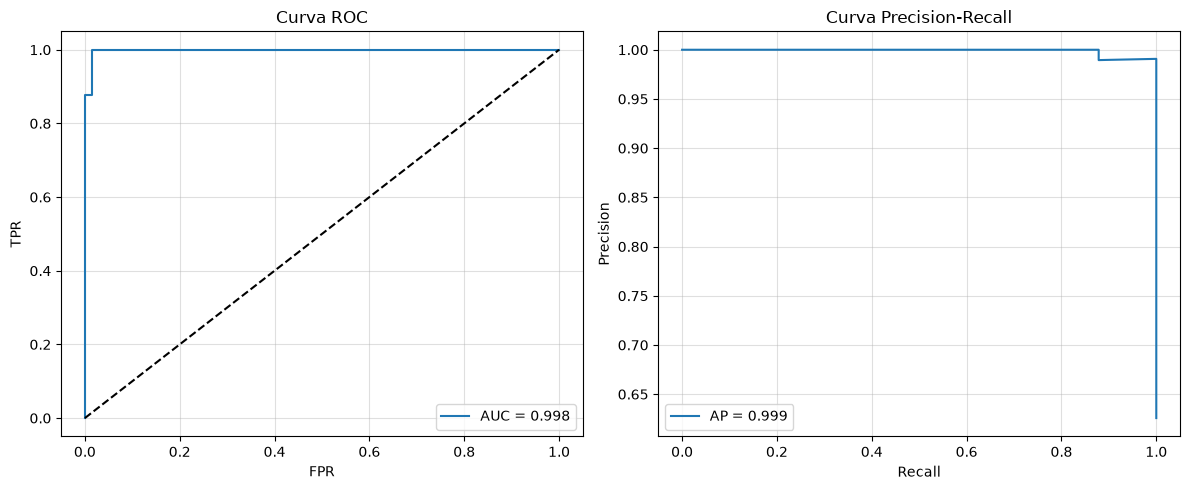

In [10]:
# Curva ROC e PR no dataset original
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(rec, prec, label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Matriz de confusao

A matriz de confusao detalha os erros: verdadeiros positivos, falsos positivos,
falsos negativos e verdadeiros negativos.

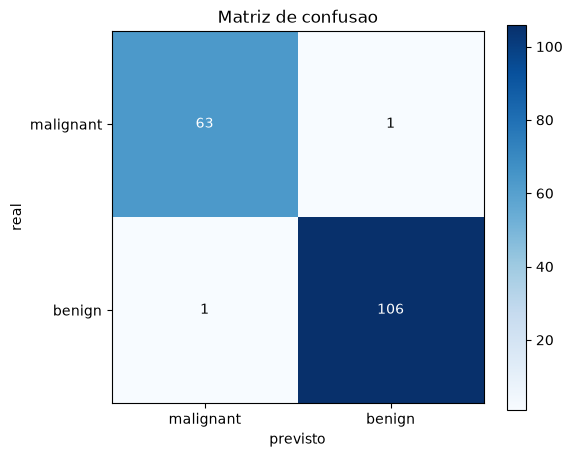

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(dados.target_names) #type: ignore
ax.set_yticklabels(dados.target_names) #type: ignore
ax.set_xlabel("previsto")
ax.set_ylabel("real")
ax.set_title("Matriz de confusao")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.show()

## Metricas de regressao

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dados_r = load_diabetes()
Xr, yr = dados_r.data, dados_r.target #type: ignore
X_tr, X_te, y_tr, y_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

modelo_r = LinearRegression().fit(X_tr, y_tr)
y_prev = modelo_r.predict(X_te)

mse = mean_squared_error(y_te, y_prev)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te, y_prev)
r2 = r2_score(y_te, y_prev)

# MAPE: erro percentual absoluto medio
mape = np.mean(np.abs((y_te - y_prev) / y_te)) * 100

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2  : {r2:.3f}")
print(f"MAPE: {mape:.2f}%")

MSE : 2900.19
RMSE: 53.85
MAE : 42.79
R2  : 0.453
MAPE: 37.50%


## Exercicios

1. Crie um dataset desbalanceado e compare acuracia, F1 e PR-AUC.
2. Encontre o limiar que maximiza F1 no dataset breast_cancer.
3. Compare MAE e RMSE em um modelo com outliers no alvo.
4. Explique quando usar ROC-AUC e quando usar PR-AUC.
5. Calcule o custo total de erros supondo que FN custa 10x mais que FP.